In [16]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon
from numpy.linalg import inv
from lifelines import CoxPHFitter
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [17]:

covariates = ["m_f", "educ", "ses", "age", "mr_delay", "e_tiv", "n_wbv", "asf"]

# Load dataset
def load_oasis_data(file_path):
    df = pd.read_excel(file_path, sheet_name="Sheet1")


    df.rename(columns={
        "Subject ID": "subject_id",
        "Visit": "visit",
        "Group": "group",
        "MR Delay": "mr_delay",
        "M/F": "m_f",
        "Age": "age",
        "EDUC": "educ",
        "SES": "ses",
        "eTIV": "e_tiv",
        "nWBV": "n_wbv",
        "ASF": "asf",
        "CDR": "cdr"
    }, inplace=True)


    df["m_f"] = df["m_f"].map({"M": 1, "F": 0})
    df["group"] = df["group"].map({"Nondemented": 0, "Demented": 1})


    df["time_of_ad"] = np.where(df["group"] == 1, df["visit"], np.nan)


    df[covariates] = df[covariates].fillna(df[covariates].median())

    return df

#  Possible pairings using Risk Set Matching
def risk_set_matching(df):
    treated = df.dropna(subset=["time_of_ad"])
    control = df[df["time_of_ad"].isna()]
    
    initial_pairings = []
    for _, t_row in treated.iterrows():
        potential_controls = control[(control["visit"] <= t_row["time_of_ad"])]
        if not potential_controls.empty:
            for _, c_row in potential_controls.iterrows():
                initial_pairings.append((t_row["subject_id"], c_row["subject_id"], t_row["time_of_ad"], c_row["visit"]))
    
    initial_pairs_df = pd.DataFrame(initial_pairings, columns=["treated", "control", "treated_time", "control_time"])
    return initial_pairs_df

# Mahalanobis Matching Optimization
def mahalanobis_matching(df, covariates, initial_pairings):
    treated = df[df["subject_id"].isin(initial_pairings["treated"])]
    control = df[df["subject_id"].isin(initial_pairings["control"])]
    

    X = control[covariates].values
    Y = treated[covariates].values
    cov_matrix = np.cov(df[covariates].T)
    inv_cov_matrix = inv(cov_matrix)

    nn = NearestNeighbors(n_neighbors=1, metric="mahalanobis", metric_params={"VI": inv_cov_matrix})
    nn.fit(X)
    distances, indices = nn.kneighbors(Y)

    matched_pairs = pd.DataFrame({
        "treated": treated["subject_id"].values,
        "control": control.iloc[indices.flatten()]["subject_id"].values,
        "distance": distances.flatten()
    })

    return matched_pairs

# Evaluate matching quality (Pre vs Post)
def evaluate_matching_quality(df, matched_pairs, covariates):
    treated_ids = matched_pairs["treated"].values
    control_ids = matched_pairs["control"].values

    treated_group = df[df["subject_id"].isin(treated_ids)]
    control_group = df[df["subject_id"].isin(control_ids)]

    # Compute mahalanobis distance 
    cov_matrix = np.cov(df[covariates].values, rowvar=False)
    inv_cov_matrix = inv(cov_matrix)

    distance_before = []
    distance_after = []

    for _, t_row in df.iterrows():
        for _, c_row in df.iterrows():
            diff = t_row[covariates] - c_row[covariates]
            distance_before.append(np.sqrt(diff.T @ inv_cov_matrix @ diff))

    for _, t_row in treated_group.iterrows():
        c_row = control_group.iloc[np.random.randint(0, len(control_group))]
        diff = t_row[covariates] - c_row[covariates]
        distance_after.append(np.sqrt(diff.T @ inv_cov_matrix @ diff))

    df_distance = pd.DataFrame({
        "Mahalanobis Distance": distance_before + distance_after,
        "Matched": ["Before Matching"] * len(distance_before) + ["After Matching"] * len(distance_after)
    })

    fig = px.histogram(df_distance, x="Mahalanobis Distance", color="Matched",
                       barmode="overlay", nbins=50,
                       title="Mahalanobis Distance Before and After Matching")
    fig.show()

# Pre vs Post-treatment comparison (Wilcoxon test)

comparison_covariates = ["mr_delay", "e_tiv", "asf"]

def pre_post_treatment_comparison(df, matched_pairs, variable):
    """
    Compare changes in the specified variable (MR delay, eTIV, ASF)
    before and after treatment using Wilcoxon signed-rank test.
    """
    
    treated_ids = matched_pairs["treated"].values
    control_ids = matched_pairs["control"].values


    treated_visit1 = df[(df["subject_id"].isin(treated_ids)) & (df["visit"] == 1)][["subject_id", variable]].dropna()
    treated_visit3 = df[(df["subject_id"].isin(treated_ids)) & (df["visit"] == 3)][["subject_id", variable]].dropna()


    control_visit1 = df[(df["subject_id"].isin(control_ids)) & (df["visit"] == 1)][["subject_id", variable]].dropna()
    control_visit3 = df[(df["subject_id"].isin(control_ids)) & (df["visit"] == 3)][["subject_id", variable]].dropna()


    treated_merged = pd.merge(treated_visit1, treated_visit3, on="subject_id", suffixes=("_v1", "_v3"))
    control_merged = pd.merge(control_visit1, control_visit3, on="subject_id", suffixes=("_v1", "_v3"))


    min_len = min(len(treated_merged), len(control_merged))
    treated_merged = treated_merged.iloc[:min_len]
    control_merged = control_merged.iloc[:min_len]


    treated_change = treated_merged[f"{variable}_v3"].values - treated_merged[f"{variable}_v1"].values
    control_change = control_merged[f"{variable}_v3"].values - control_merged[f"{variable}_v1"].values


    if len(treated_change) > 0 and len(control_change) > 0:
        stat, p_value = wilcoxon(treated_change, control_change)
        print(f"Wilcoxon test for {variable}: statistic={stat}, p-value={p_value}")
    else:
        print(f"Skipping Wilcoxon test for {variable}: Not enough matching data.")

    return treated_merged[f"{variable}_v1"].values, treated_merged[f"{variable}_v3"].values, treated_change, \
           control_merged[f"{variable}_v1"].values, control_merged[f"{variable}_v3"].values, control_change


def plot_comparison_boxplots(df, matched_pairs):
    """
    Create 6 pairs of boxplots:
    - 2 pairs for baseline comparability (Visit 1 vs. Visit 3)
    - 4 pairs for outcome comparisons (Change from Visit 1 to Visit 3)
    """
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    fig.suptitle("Pre- and Post-Treatment Comparisons", fontsize=16)

    for i, variable in enumerate(comparison_covariates):
        treated_v1, treated_v3, treated_change, control_v1, control_v3, control_change = pre_post_treatment_comparison(df, matched_pairs, variable)


        data = pd.DataFrame({
            "Visit": ["Visit 1"] * len(treated_v1) + ["Visit 3"] * len(treated_v3) +
                     ["Visit 1"] * len(control_v1) + ["Visit 3"] * len(control_v3),
            "Group": ["Treated"] * (len(treated_v1) + len(treated_v3)) +
                     ["Never/Later Treated"] * (len(control_v1) + len(control_v3)),
            variable: np.concatenate([treated_v1, treated_v3, control_v1, control_v3])
        })


        sns.boxplot(x="Visit", y=variable, hue="Group", data=data, ax=axes[i, 0])
        axes[i, 0].set_title(f"{variable} - Pre-Treatment")
        axes[i, 0].set_ylabel(variable)

       
        change_data = pd.DataFrame({
            "Change": np.concatenate([treated_change, control_change]),
            "Group": ["Treated"] * len(treated_change) + ["Never/Later Treated"] * len(control_change)
        })


        sns.boxplot(x="Group", y="Change", data=change_data, ax=axes[i, 1])
        axes[i, 1].set_title(f"{variable} - Post-Treatment")
        axes[i, 1].set_ylabel(f"Change in {variable} (Visit 3 - Visit 1)")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
# sensitivity Analysis
def sensitivity_analysis(df, matched_pairs, gamma_values=np.arange(0.1, 2.1, 0.1)):
    treated_ids = matched_pairs["treated"].values
    control_ids = matched_pairs["control"].values


    treated_group = df[df["subject_id"].isin(treated_ids)][["subject_id", "cdr"]].dropna()
    control_group = df[df["subject_id"].isin(control_ids)][["subject_id", "cdr"]].dropna()

 
    treated_group = treated_group.set_index("subject_id").loc[treated_ids]
    control_group = control_group.set_index("subject_id").loc[control_ids]


    treated_cdr = treated_group["cdr"].values
    control_cdr = control_group["cdr"].values


    min_len = min(len(treated_cdr), len(control_cdr))
    treated_cdr = treated_cdr[:min_len]
    control_cdr = control_cdr[:min_len]


    outcome_diff = treated_cdr - control_cdr
    results = []


    for gamma in gamma_values:
        bound = gamma * np.std(outcome_diff)
        significant = np.abs(outcome_diff.mean()) > bound
        results.append((gamma, significant))


    df_sensitivity = pd.DataFrame(results, columns=["Gamma", "Significant"])


    fig = px.line(df_sensitivity, x="Gamma", y="Significant",
                  title="Sensitivity Analysis: Effect of Hidden Bias",
                  markers=True)
    fig.show()


Initial Possible Pairings by Risk Set Matching:
     treated    control  treated_time  control_time
0  OAS2_0002  OAS2_0001           1.0             1
1  OAS2_0002  OAS2_0004           1.0             1
2  OAS2_0002  OAS2_0005           1.0             1
3  OAS2_0002  OAS2_0008           1.0             1
4  OAS2_0002  OAS2_0012           1.0             1
5  OAS2_0002  OAS2_0013           1.0             1
6  OAS2_0002  OAS2_0017           1.0             1
7  OAS2_0002  OAS2_0018           1.0             1
8  OAS2_0002  OAS2_0020           1.0             1
9  OAS2_0002  OAS2_0022           1.0             1
Optimized Matched Pairs:
     treated    control  distance
0  OAS2_0002  OAS2_0005  0.097372
1  OAS2_0002  OAS2_0143  0.256532
2  OAS2_0002  OAS2_0070  0.275676
3  OAS2_0007  OAS2_0036  0.020537
4  OAS2_0007  OAS2_0027  0.156850
5  OAS2_0007  OAS2_0027  0.155746
6  OAS2_0009  OAS2_0051  0.014543
7  OAS2_0009  OAS2_0178  0.092921
8  OAS2_0010  OAS2_0177  0.019106
9  OAS2_0010  O

Wilcoxon test for mr_delay: statistic=59.0, p-value=0.668548583984375
Wilcoxon test for e_tiv: statistic=61.0, p-value=0.743560791015625
Wilcoxon test for asf: statistic=61.0, p-value=0.743560791015625


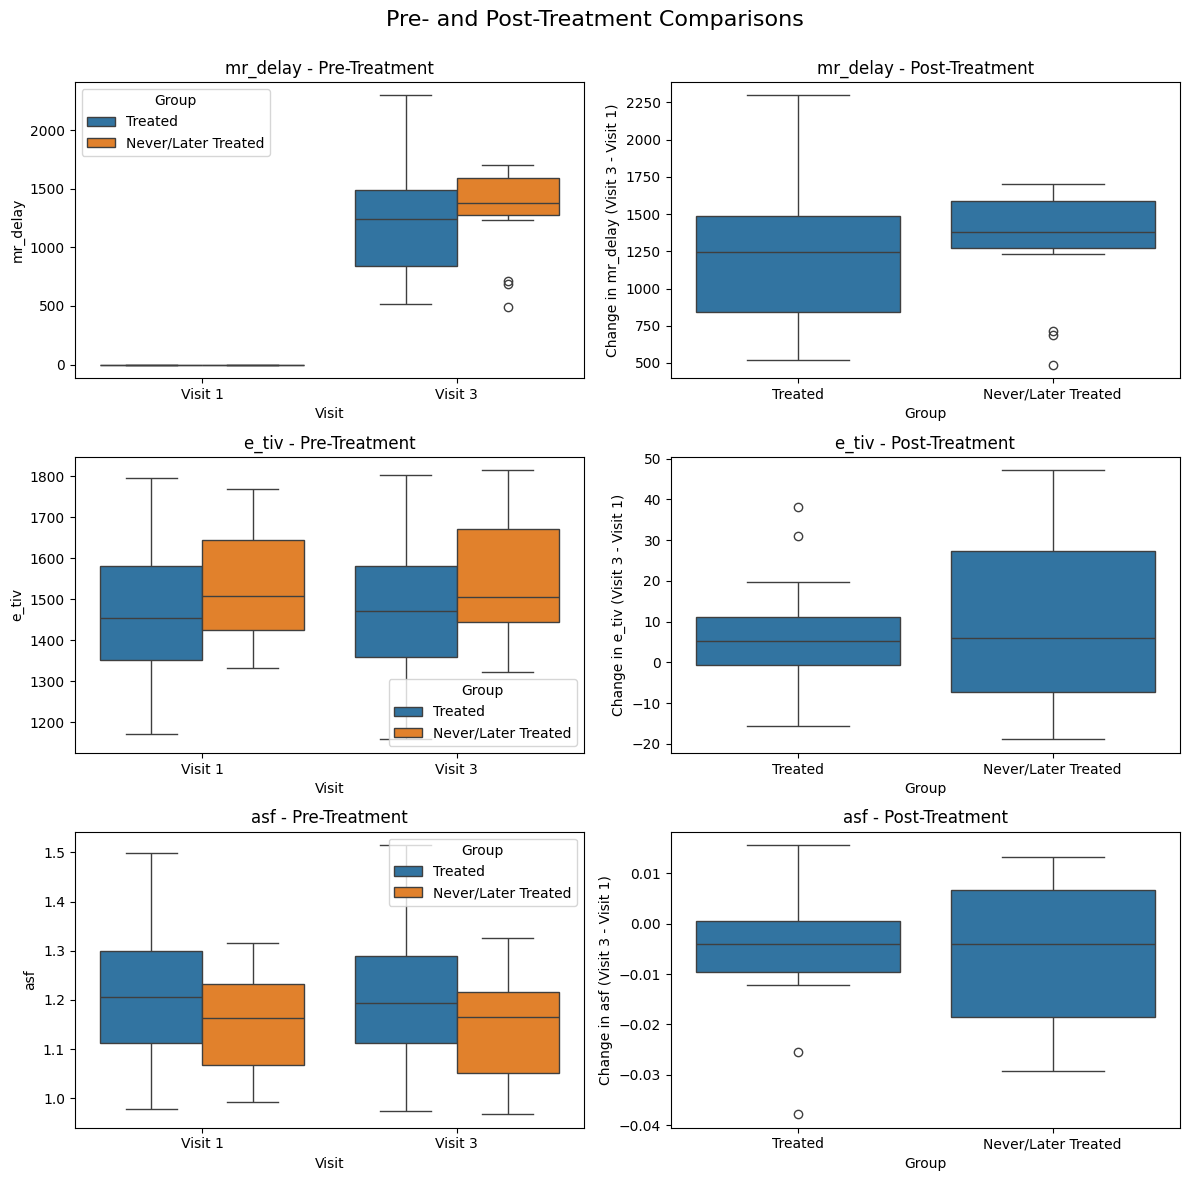

In [ ]:

if __name__ == "__main__":
    data_file = "oasis_data.xlsx"
    df = load_oasis_data(data_file)


    initial_pairings = risk_set_matching(df)
    print("Initial Possible Pairings by Risk Set Matching:")
    print(initial_pairings.head(10))


    matched_pairs = mahalanobis_matching(df, comparison_covariates, risk_set_matching(df))
    print("Optimized Matched Pairs:")
    print(matched_pairs.head(10))

    evaluate_matching_quality(df, matched_pairs, covariates)

    plot_comparison_boxplots(df, matched_pairs)

    sensitivity_analysis(df, matched_pairs)